### 傳統 ML 模型訓練與比較

In [ ]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')  # 添加父目錄到Python路徑
from src.evaluate import evaluate_model, evaluate_threshold, plot_feature_importance_xgb
from src.visualization.plotting import visualize_threshold_results

df = pd.read_csv('../data/cleaned_encoded_data.csv')
print(df.appointment_shift.head(5))
df.isna().sum()
df.info()

0    0
1    0
2    0
3    0
4    0
Name: appointment_shift, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46634 entries, 0 to 46633
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          46634 non-null  float64
 1   no_show                         46634 non-null  int64  
 2   icd                             10216 non-null  object 
 3   appointment_shift               46634 non-null  int64  
 4   age                             37943 non-null  float64
 5   under_12_years_old              46634 non-null  int64  
 6   over_60_years_old               46634 non-null  int64  
 7   patient_needs_companion         46634 non-null  int64  
 8   average_temp_day                45930 non-null  float64
 9   average_rain_day                45930 non-null  float64
 10  max_temp_day                    45930 non-null  float64
 11  max_rain_day        

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46634 entries, 0 to 46633
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          46634 non-null  float64
 1   no_show                         46634 non-null  int64  
 2   icd                             10216 non-null  object 
 3   appointment_shift               46634 non-null  int64  
 4   age                             37943 non-null  float64
 5   under_12_years_old              46634 non-null  int64  
 6   over_60_years_old               46634 non-null  int64  
 7   patient_needs_companion         46634 non-null  int64  
 8   average_temp_day                45930 non-null  float64
 9   average_rain_day                45930 non-null  float64
 10  max_temp_day                    45930 non-null  float64
 11  max_rain_day                    45930 non-null  float64
 12  rainy_day_before                

In [3]:
# Split Features and Target
X = df.drop(columns=['no_show', 'icd'])
y = df['no_show']


In [4]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # Stratify to maintain the distribution of the target variable in both train and test sets


### Model Training 
#### 1. Logistic Regression
#### 2. SVM
#### 3. Random Forest 
#### 4. XGboost 

In [5]:

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# import standard scaler
from sklearn.preprocessing import StandardScaler


In [6]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
### Add Imputer and Missing indicators for missing values
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler

# 首先創建缺失值指示器
missing_indicator = X_train['age'].isna().astype(int).values.reshape(-1, 1)
missing_indicator_test = X_test['age'].isna().astype(int).values.reshape(-1, 1)

# 創建和使用 imputer: missing value indicator + imputed features
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 將缺失值指示器與縮放後的特徵組合
X_train_final = np.hstack((missing_indicator, X_train_scaled))
X_test_final = np.hstack((missing_indicator_test, X_test_scaled))

# Final Features: X_train_final, X_test_final (Imbalanced)


In [8]:
# Fix Imbalance data using SMOTE: X_train_balanced, y_train_balanced
print("Before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print("After SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
no_show
0    33579
1     3728
Name: count, dtype: int64
After SMOTE:
no_show
0    33579
1    33579
Name: count, dtype: int64


#### 1. X_train_final: Original imbalanced data with imputation and missing indicators, pair with Random Forest using class_weight#
#### 2. X_train_balanced: Balanced data using SMOTE: includes synthetic data, might not reflect true conditions

In [9]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [10]:
y_pred_lg = logreg.predict(X_test_final)
y_proba_lg = logreg.predict_proba(X_test_final)[:, 1]

#### Evaluation Metrics:
1. Accuracy = (TP + TN) / (TP + FP + TN + FN) 
2. Precision = TP / (TP + FN) 
3. Recall = TP / (TP + EN) -> 成功預測出來的比例
4. F1 Score = 2 * (Precision + Recall) / (Precision + Recall) 
5. ROC AUC

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

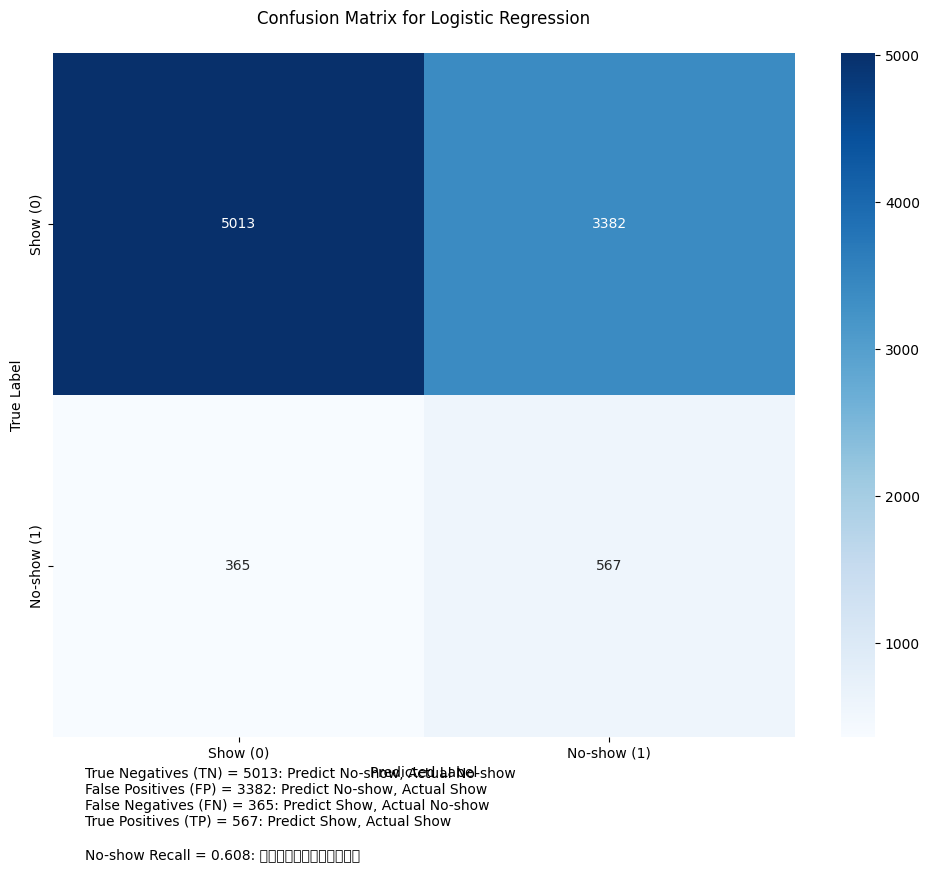

              precision    recall  f1-score   support

           0       0.93      0.60      0.73      8395
           1       0.14      0.61      0.23       932

    accuracy                           0.60      9327
   macro avg       0.54      0.60      0.48      9327
weighted avg       0.85      0.60      0.68      9327

roc_auc:  0.6390807168583383


{'precision': 0.14358065332995695,
 'recall': 0.6083690987124464,
 'f1': 0.23232944068838352,
 'accuracy': np.float64(0.598263107108395),
 'roc_auc': np.float64(0.6390807168583383),
 'true_positives': np.int64(567),
 'false_positives': np.int64(3382),
 'true_negatives': np.int64(5013),
 'false_negatives': np.int64(365)}

In [11]:
evaluate_model(y_test, y_pred_lg, y_proba_lg, "Logistic Regression")

In [12]:
## Adjust threshold to improve recall
results_df = evaluate_threshold(y_test, y_proba_lg)
visualize_threshold_results(results_df)


Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.95      0.24      0.39      8395
           1       0.11      0.89      0.20       932

    accuracy                           0.31      9327
   macro avg       0.53      0.56      0.29      9327
weighted avg       0.87      0.31      0.37      9327



## SVM

In [42]:
from sklearn.svm import SVC

# 2. 定義和訓練 SVM 模型
svm_model = SVC(
    kernel='rbf',  # 使用 RBF 核函數
    probability=True,  # 需要這個來獲得概率預測
    class_weight='balanced',  # 處理類別不平衡
    random_state=42
)

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
# 3. 使用 GridSearchCV 尋找最佳參數
param_grid_svm = {
    'C': [1],           # 先只用默認值
    'gamma': ['scale'], # 先只用默認值
    'class_weight': ['balanced', {0:1, 1:10}]  # 只測試兩種權重
}

# 2. 減少交叉驗證折數
grid_svm = GridSearchCV(
    svm_model,
    param_grid_svm,
    scoring={
        'recall': make_scorer(recall_score, pos_label=1),
        'roc_auc': 'roc_auc'
    },
    refit='recall',
    cv=3,  # 從5減到3
    n_jobs=-1,
    verbose=2
)

# 4. 訓練模型
print("Training SVM model...")
grid_svm.fit(X_train_scaled, y_train)




Training SVM model...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END .......C=1, class_weight={0: 1, 1: 10}, gamma=scale; total time= 8.1min
[CV] END .......C=1, class_weight={0: 1, 1: 10}, gamma=scale; total time= 8.1min
[CV] END ............C=1, class_weight=balanced, gamma=scale; total time= 8.2min
[CV] END ............C=1, class_weight=balanced, gamma=scale; total time= 8.2min
[CV] END .......C=1, class_weight={0: 1, 1: 10}, gamma=scale; total time= 8.2min
[CV] END ............C=1, class_weight=balanced, gamma=scale; total time= 8.3min


GridSearchCV(cv=3,
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid={'C': [1], 'class_weight': ['balanced', {0: 1, 1: 10}],
                         'gamma': ['scale']},
             refit='recall',
             scoring={'recall': make_scorer(recall_score, response_method='predict', pos_label=1),
                      'roc_auc': 'roc_auc'},
             verbose=2)


SVM Model Evaluation:
Best parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

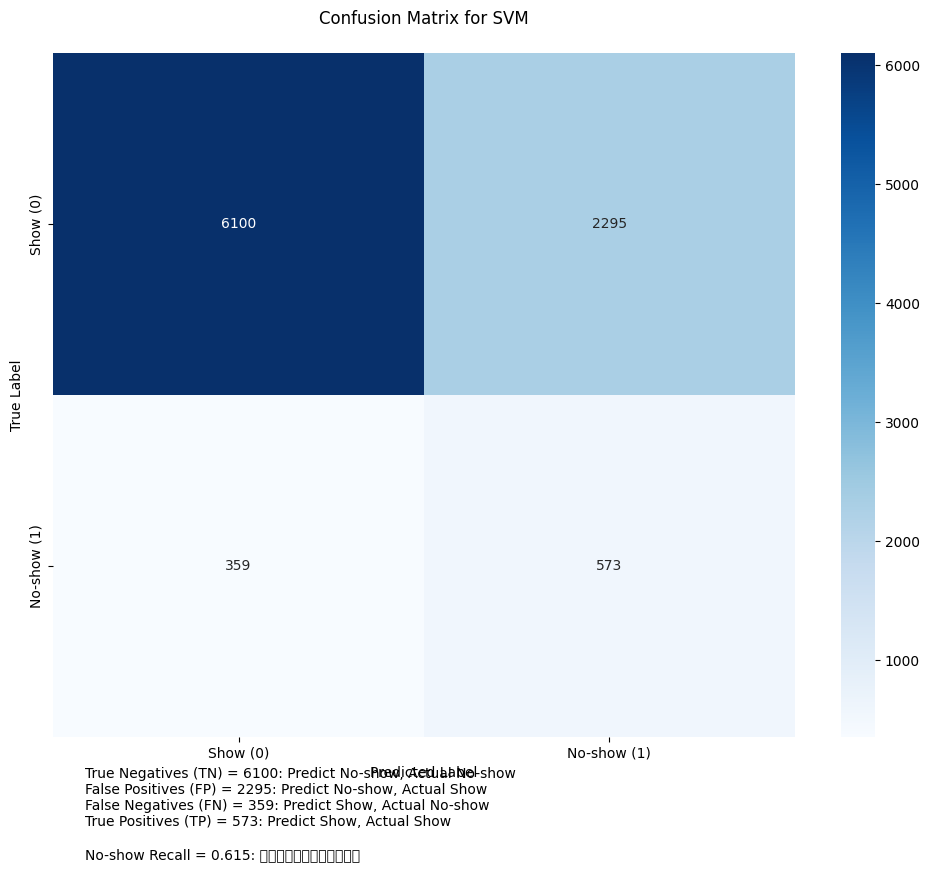

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      8395
           1       0.20      0.61      0.30       932

    accuracy                           0.72      9327
   macro avg       0.57      0.67      0.56      9327
weighted avg       0.87      0.72      0.77      9327

roc_auc:  0.716490630280133
Best threshold based on cost savings: 0.1


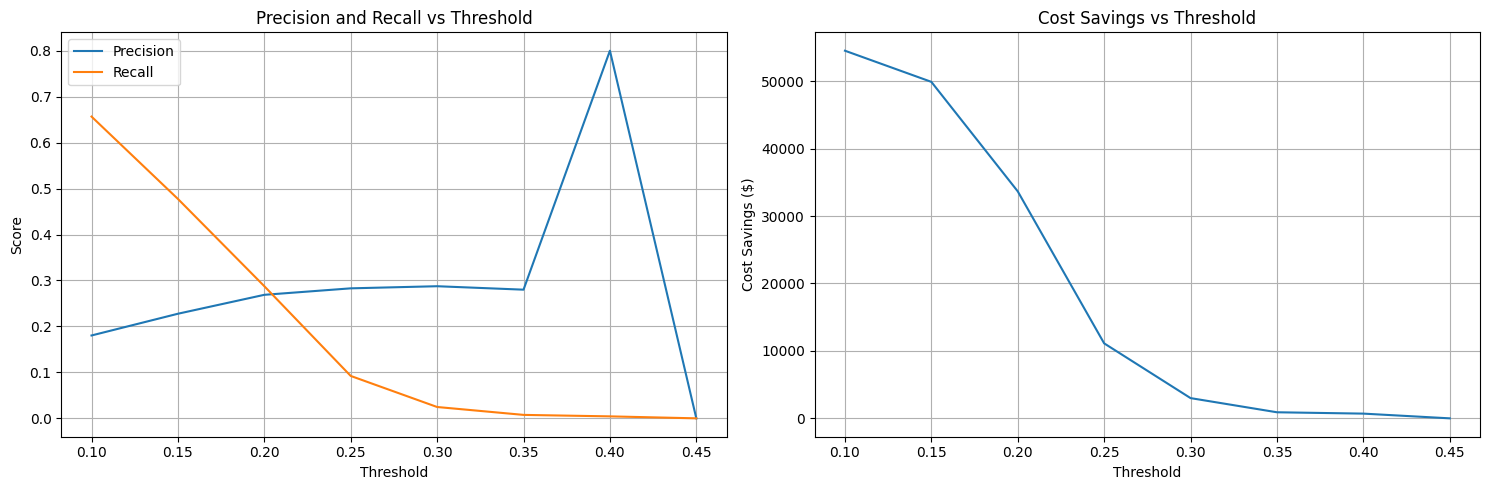


Best Threshold Results:
Threshold: 0.100
Precision: 0.180
Recall: 0.657
Cost Savings: $54,520.00
True Positives: 612.0
False Positives: 2782.0
False Negatives: 320.0


In [50]:
# 5. 獲取最佳模型
best_svm = grid_svm.best_estimator_

# 6. 進行預測
y_pred_svm = best_svm.predict(X_test_scaled)
y_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

# 7. 評估模型
print("\nSVM Model Evaluation:")
print("Best parameters:", grid_svm.best_params_)

evaluate_model(y_test, y_pred_svm, y_proba_svm, "SVM")
results_df = evaluate_threshold(y_test, y_proba_svm)
visualize_threshold_results(results_df)

## Random Forest 

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight=None        # SMOTE already handled imbalance
)

rf_model.fit(X_train_balanced, y_train_balanced)


RandomForestClassifier(random_state=42)

In [14]:
y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]  # needed for AUC

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

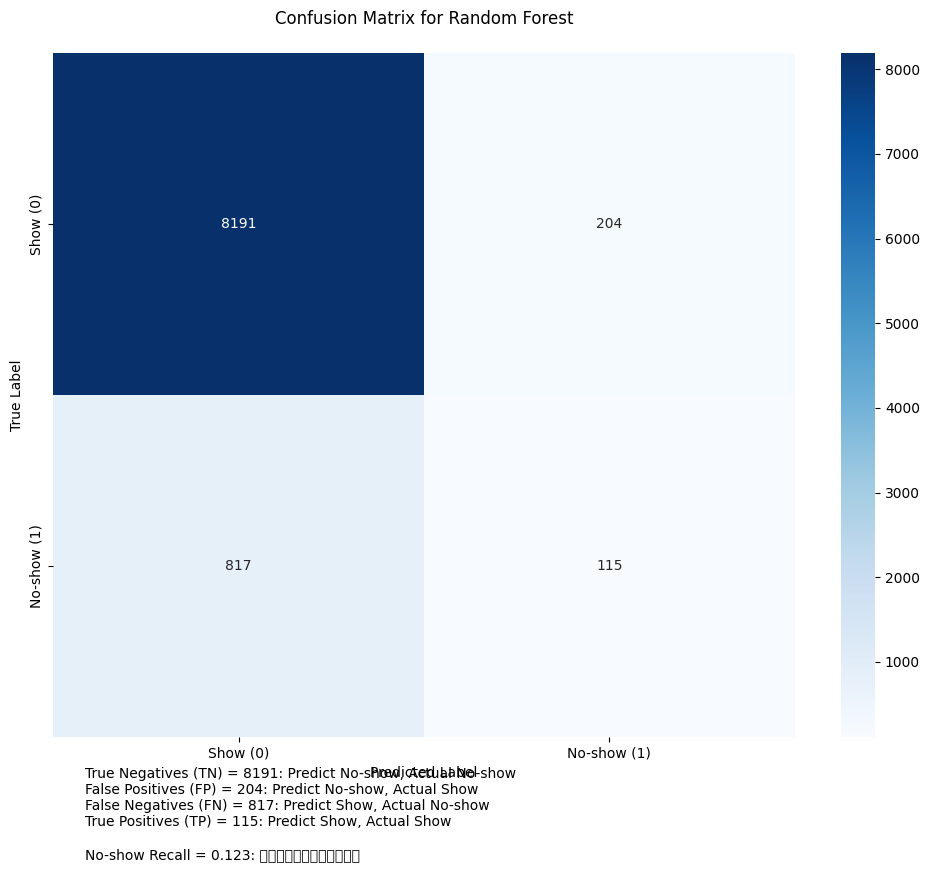

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.36      0.12      0.18       932

    accuracy                           0.89      9327
   macro avg       0.63      0.55      0.56      9327
weighted avg       0.85      0.89      0.87      9327

roc_auc:  0.742568767941269


{'precision': 0.3605015673981191,
 'recall': 0.12339055793991416,
 'f1': 0.1838529176658673,
 'accuracy': np.float64(0.8905328615846467),
 'roc_auc': np.float64(0.742568767941269),
 'true_positives': np.int64(115),
 'false_positives': np.int64(204),
 'true_negatives': np.int64(8191),
 'false_negatives': np.int64(817)}

In [ ]:
## Initial Model
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")


In [16]:
## Weighted models (Dealing with the Imbalanced Dataset)
rf_model_2 = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight='balanced',        
    min_samples_split=2
)

rf_model_2.fit(X_train_final, y_train)
y_pred_rf_weighted = rf_model_2.predict(X_test_final)
y_proba_rf_weighted = rf_model_2.predict_proba(X_test_final)[:, 1]  # needed for AUC

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

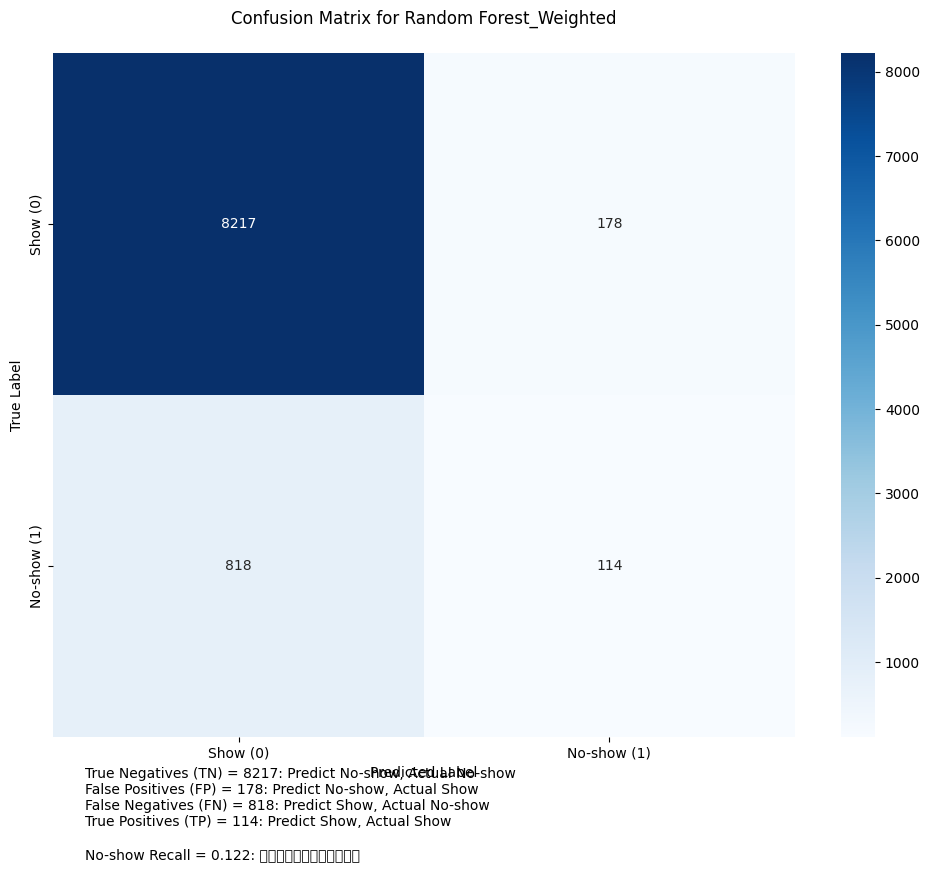

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.39      0.12      0.19       932

    accuracy                           0.89      9327
   macro avg       0.65      0.55      0.56      9327
weighted avg       0.86      0.89      0.87      9327

roc_auc:  0.7795906642774796
Best threshold based on cost savings: 0.1


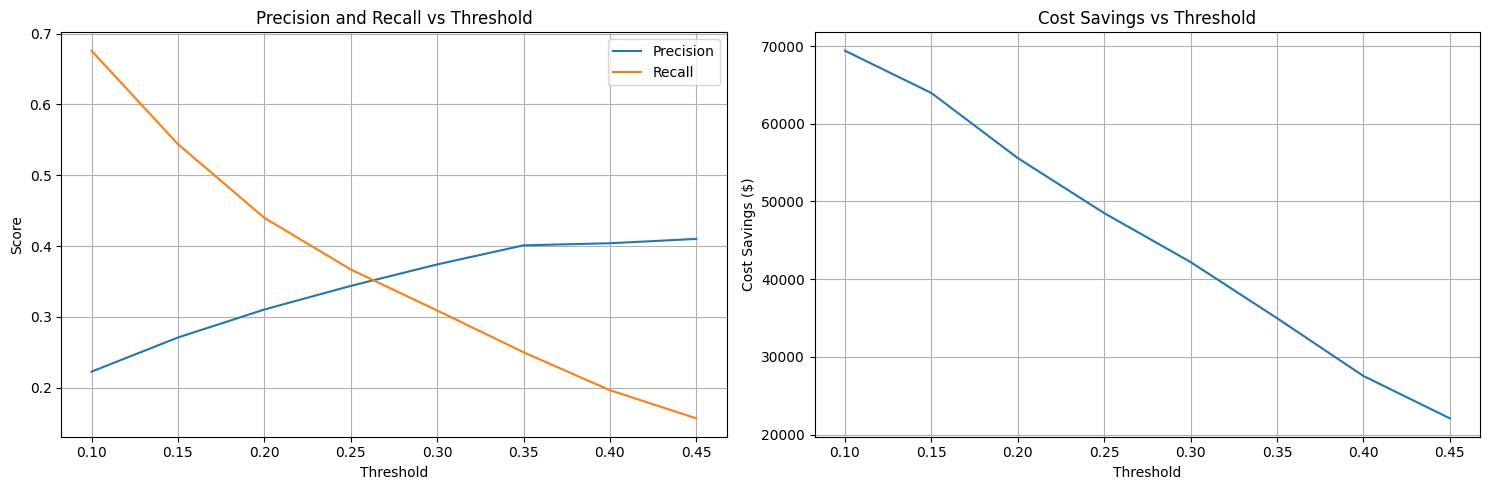


Best Threshold Results:
Threshold: 0.100
Precision: 0.223
Recall: 0.676
Cost Savings: $69,400.00
True Positives: 630.0
False Positives: 2200.0
False Negatives: 302.0


In [ ]:
evaluate_model(y_test, y_pred_rf_weighted, y_proba_rf_weighted, "Random Forest_Weighted")

# Determine the best threshold for cost saving
results_df = evaluate_threshold(y_test, y_proba_rf_weighted)
visualize_threshold_results(results_df)


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

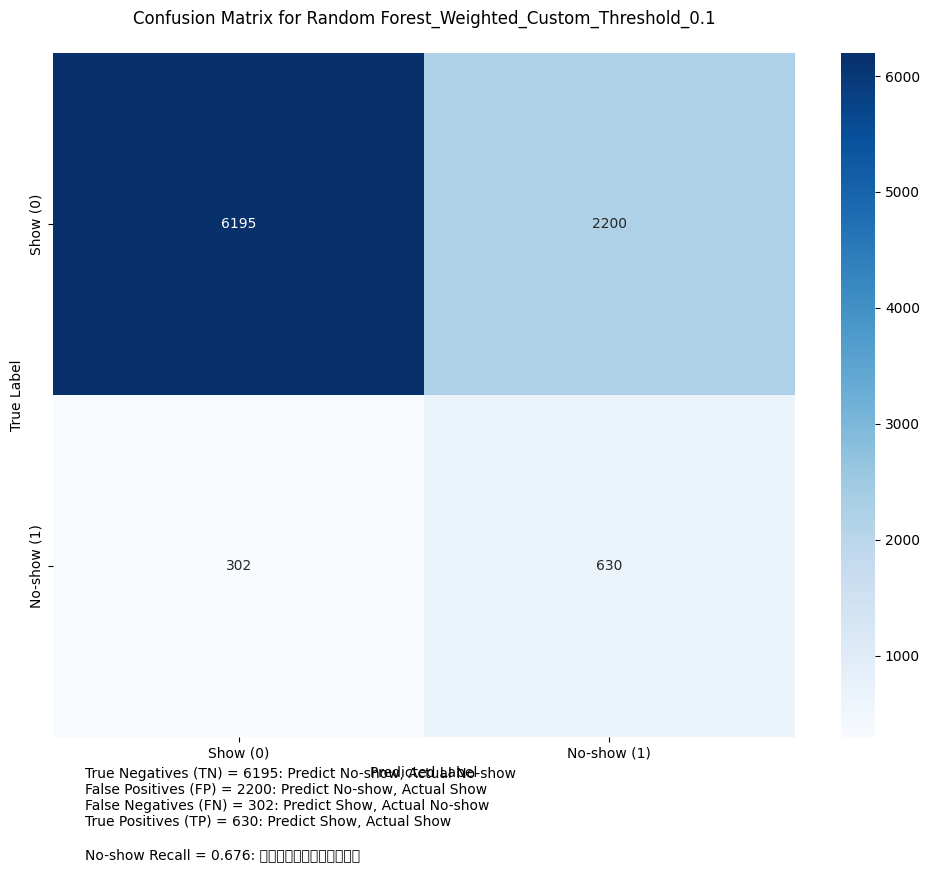

              precision    recall  f1-score   support

           0       0.95      0.74      0.83      8395
           1       0.22      0.68      0.33       932

    accuracy                           0.73      9327
   macro avg       0.59      0.71      0.58      9327
weighted avg       0.88      0.73      0.78      9327

roc_auc:  0.7795906642774796


{'precision': 0.2226148409893993,
 'recall': 0.6759656652360515,
 'f1': 0.3349282296650718,
 'accuracy': np.float64(0.7317465422965583),
 'roc_auc': np.float64(0.7795906642774796),
 'true_positives': np.int64(630),
 'false_positives': np.int64(2200),
 'true_negatives': np.int64(6195),
 'false_negatives': np.int64(302)}

In [58]:
threshold = 0.1
y_pred_custom = (y_proba_rf_weighted >= threshold).astype(int)
evaluate_model(y_test, y_pred_custom, y_proba_rf_weighted, "Random Forest_Weighted_Custom_Threshold_0.1")


In [60]:
# 1. Grid Search Paramters
param_grid_rf_fine = {
    'n_estimators': [180, 200, 220],  # 圍繞200探索
    'max_depth': [None, 30, 40],      # 測試是否需要限制深度
    'min_samples_split': [2, 3],      # 微調分割條件
    'min_samples_leaf': [1, 2],       # 控制葉節點大小
    'max_features': ['sqrt', 'log2'],  # 特徵選擇方法
    'class_weight': [
        'balanced',
        {0:1, 1:8},
        {0:1, 1:10},
        {0:1, 1:12}
    ]  # 更細緻的類別權重
}

# Define Cost Saving to used as Scoring 
def calculate_cost_savings(cm_values):
    """計算成本節省"""
    tn, fp, fn, tp = cm_values
    savings = tp * 200  # 每個正確預測的no-show節省200
    costs = (fp * 20)   # 每個誤報成本20
    missed = fn * 200   # 每個漏報成本200
    return savings - costs - missed

# 2. 使用多個評估指標的 GridSearchCV
grid_rf_fine = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf_fine,
    scoring={
        'recall': make_scorer(recall_score, pos_label=1),  # no-show的召回率
        'roc_auc': 'roc_auc',                             # 整體表現
        'cost_savings': make_scorer(
            lambda y_true, y_pred: calculate_cost_savings(
                confusion_matrix(y_true, y_pred).ravel()
            )
        )  # 自定義成本評分
    },
    refit='cost_savings',  # 使用成本節省作為選擇標準
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("開始微調...")
grid_rf_fine.fit(X_train, y_train)

開始微調...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   7.9s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   8.0s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   8.1s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   8.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   8.5s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   8.6s
[CV] END class_weight=balanced, max_depth=None, max_featur

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 8},
                                          {0: 1, 1: 10}, {0: 1, 1: 12}],
                         'max_depth': [None, 30, 40],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [180, 200, 220]},
             refit='cost_savings',
             scoring={'cost_savings': make_scorer(<lambda>, response_method='predict'),
                      'recall': make_scorer(recall_score, response_method='predict', pos_label=1),
                      'roc_auc': 'roc_auc'},
             verbose=2)


最佳參數: {'class_weight': {0: 1, 1: 12}, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 220}

最佳模型評估:


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

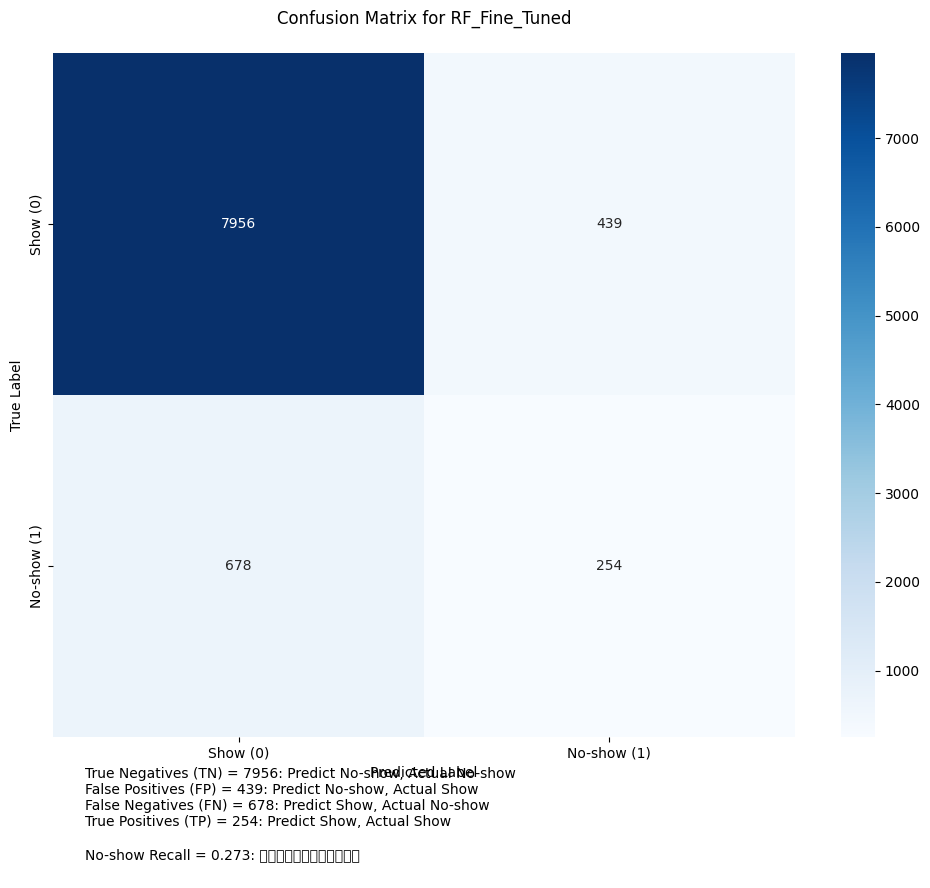

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8395
           1       0.37      0.27      0.31       932

    accuracy                           0.88      9327
   macro avg       0.64      0.61      0.62      9327
weighted avg       0.87      0.88      0.87      9327

roc_auc:  0.7780449991947996
Best threshold based on cost savings: 0.25000000000000006

閾值優化結果:
   threshold  true_positives  false_positives  false_negatives    recall  \
3       0.25             698             2709              234  0.748927   
4       0.30             604             1943              328  0.648069   
2       0.20             788             3796              144  0.845494   
5       0.35             483             1373              449  0.518240   
6       0.40             405              961              527  0.434549   

   precision  cost_savings  
3   0.204872         71460  
4   0.237142         69860  
2   0.171902         65920  
5   

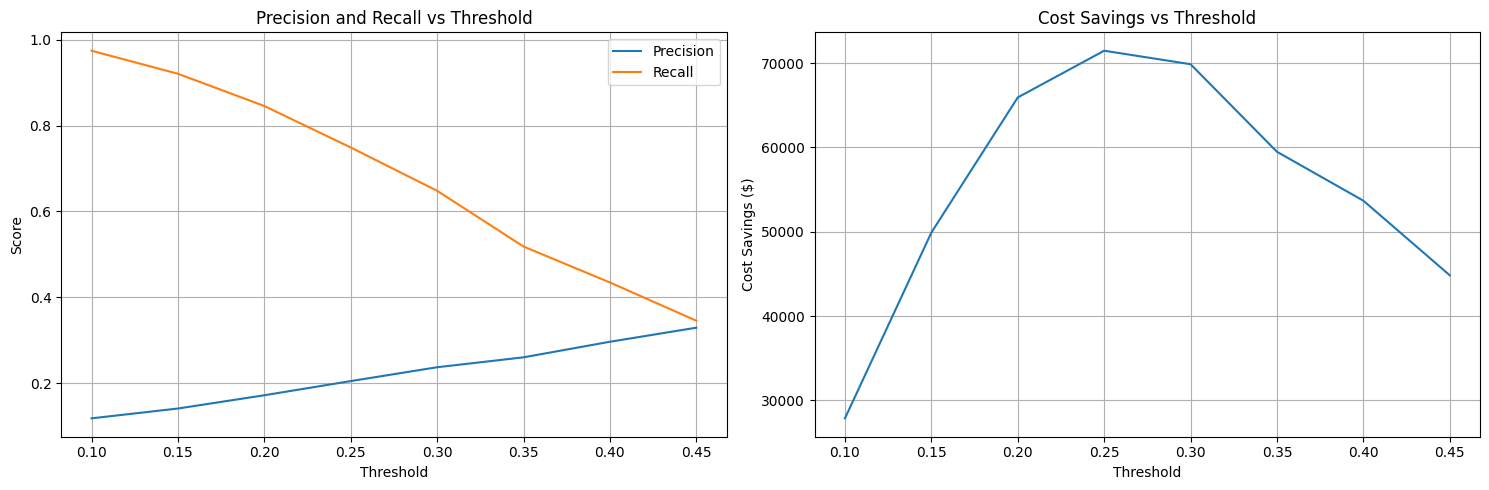


Best Threshold Results:
Threshold: 0.250
Precision: 0.205
Recall: 0.749
Cost Savings: $71,460.00
True Positives: 698.0
False Positives: 2709.0
False Negatives: 234.0

最重要的特徵:
              feature  importance
6    average_temp_day    0.097533
8        max_temp_day    0.089988
2                 age    0.071951
7    average_rain_day    0.054966
9        max_rain_day    0.050794
13     heat_intensity    0.022713
0              gender    0.021014
27        city_ITAJAÍ    0.019769
12     rain_intensity    0.018102
1   appointment_shift    0.017457


In [75]:

# 5. 獲取最佳模型
best_rf = grid_rf_fine.best_estimator_
print("\n最佳參數:", grid_rf_fine.best_params_)

# 6. 評估最佳模型
y_pred_rf_weighted_best = best_rf.predict(X_test)
y_proba_rf_weighted_best = best_rf.predict_proba(X_test)[:, 1]

# 7. 詳細評估
print("\n最佳模型評估:")
evaluate_model(y_test, y_pred_rf_weighted_best, y_proba_rf_weighted_best, "RF_Fine_Tuned")

# 8. 閾值優化
results_df = evaluate_threshold(y_test, y_proba_rf_weighted_best)
print("\n閾值優化結果:")
print(results_df.sort_values('cost_savings', ascending=False).head())

visualize_threshold_results(results_df)

# 9. 特徵重要性分析
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n最重要的特徵:")
print(feature_importance.head(10))



/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

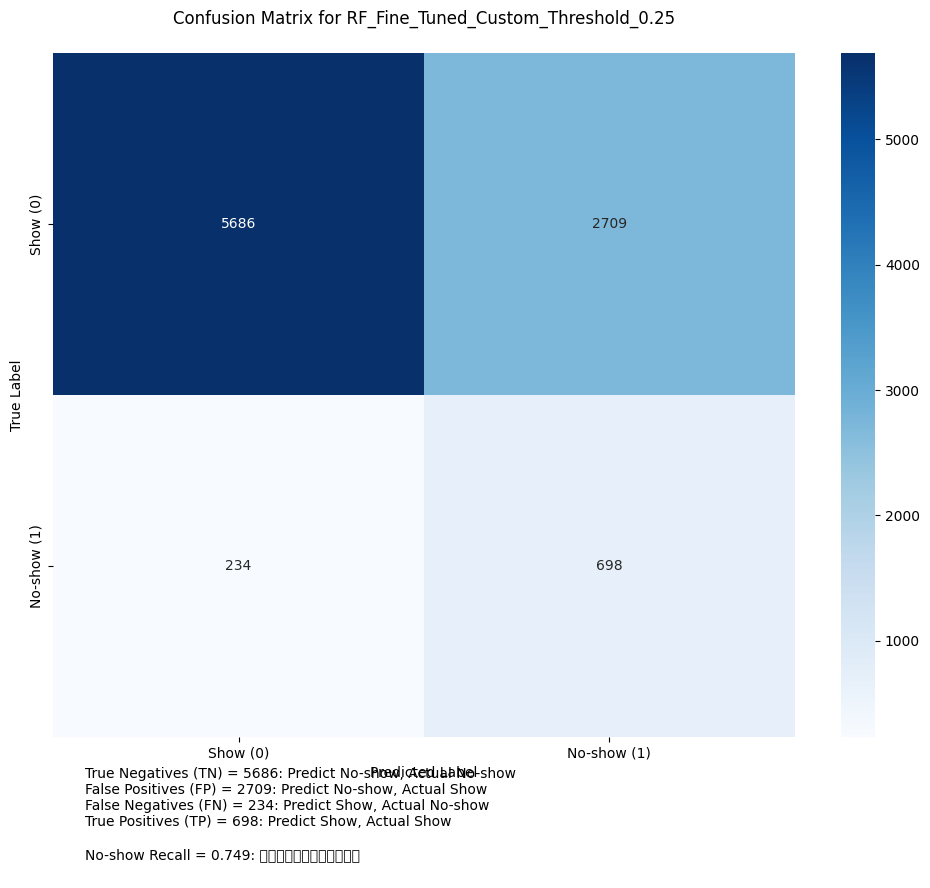

              precision    recall  f1-score   support

           0       0.96      0.68      0.79      8395
           1       0.20      0.75      0.32       932

    accuracy                           0.68      9327
   macro avg       0.58      0.71      0.56      9327
weighted avg       0.88      0.68      0.75      9327

roc_auc:  0.7780449991947996


{'precision': 0.20487232169063693,
 'recall': 0.7489270386266095,
 'f1': 0.3217331182300069,
 'accuracy': np.float64(0.6844644580250885),
 'roc_auc': np.float64(0.7780449991947996),
 'true_positives': np.int64(698),
 'false_positives': np.int64(2709),
 'true_negatives': np.int64(5686),
 'false_negatives': np.int64(234)}

In [66]:
threshold = 0.25
y_pred_custom = (y_proba_rf_weighted_best >= threshold).astype(int)
evaluate_model(y_test, y_pred_custom, y_proba_rf_weighted_best, "RF_Fine_Tuned_Custom_Threshold_0.25")


## No differences between weighted and SMOTE
1. SMOTE creates synthetic examples that may not generalize well

2. Random Forest already does internal bootstrapping + averaging

3. Giving the model correct penalties via class weights is more elegant and stable



In [85]:
grid_rf_fine.fit(X_train_final, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   6.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   6.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   6.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   6.7s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=   6.8s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   7.0s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt,

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 8},
                                          {0: 1, 1: 10}, {0: 1, 1: 12}],
                         'max_depth': [None, 30, 40],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [180, 200, 220]},
             refit='cost_savings',
             scoring={'cost_savings': make_scorer(<lambda>, response_method='predict'),
                      'recall': make_scorer(recall_score, response_method='predict', pos_label=1),
                      'roc_auc': 'roc_auc'},
             verbose=2)


最佳參數: {'class_weight': {0: 1, 1: 12}, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

最佳模型評估:


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

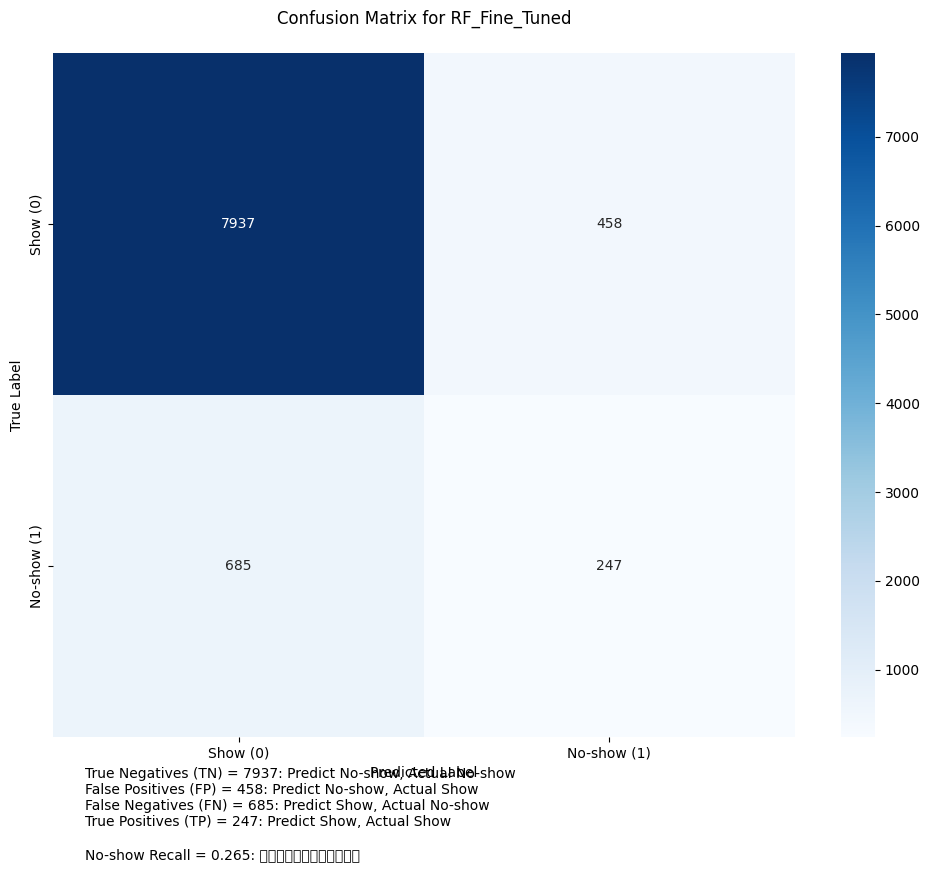

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8395
           1       0.35      0.27      0.30       932

    accuracy                           0.88      9327
   macro avg       0.64      0.61      0.62      9327
weighted avg       0.86      0.88      0.87      9327

roc_auc:  0.7791211558075394
Best threshold based on cost savings: 0.30000000000000004

閾值優化結果:
   threshold  true_positives  false_positives  false_negatives    recall  \
4       0.30             611             1938              321  0.655579   
3       0.25             698             2755              234  0.748927   
2       0.20             784             3898              148  0.841202   
5       0.35             504             1395              428  0.540773   
6       0.40             414              968              518  0.444206   

   precision  cost_savings  
4   0.239702         71220  
3   0.202143         70540  
2   0.167450         63160  
5   

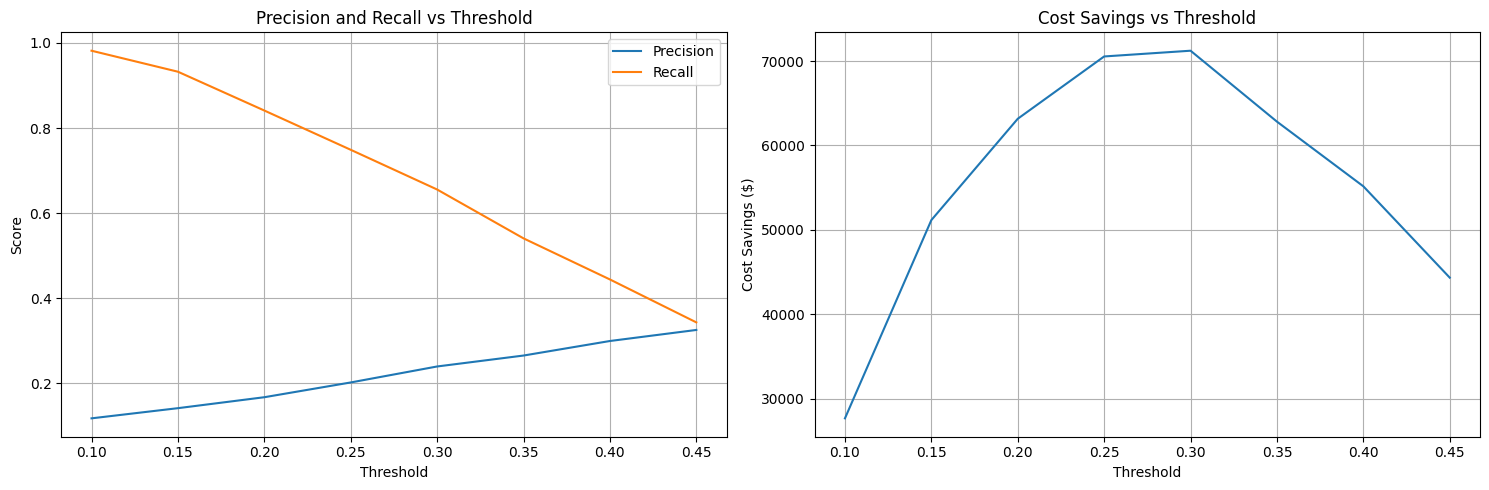


Best Threshold Results:
Threshold: 0.300
Precision: 0.240
Recall: 0.656
Cost Savings: $71,220.00
True Positives: 611.0
False Positives: 1938.0
False Negatives: 321.0


In [93]:
# 5. 獲取最佳模型
best_rf = grid_rf_fine.best_estimator_
print("\n最佳參數:", grid_rf_fine.best_params_)

# 6. 評估最佳模型
y_pred_rf_weighted_best = best_rf.predict(X_test_final)
y_proba_rf_weighted_best = best_rf.predict_proba(X_test_final)[:, 1]

# 7. 詳細評估
print("\n最佳模型評估:")
evaluate_model(y_test, y_pred_rf_weighted_best, y_proba_rf_weighted_best, "RF_Fine_Tuned")

# 8. 閾值優化
results_df = evaluate_threshold(y_test, y_proba_rf_weighted_best)
print("\n閾值優化結果:")
print(results_df.sort_values('cost_savings', ascending=False).head())

visualize_threshold_results(results_df)

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

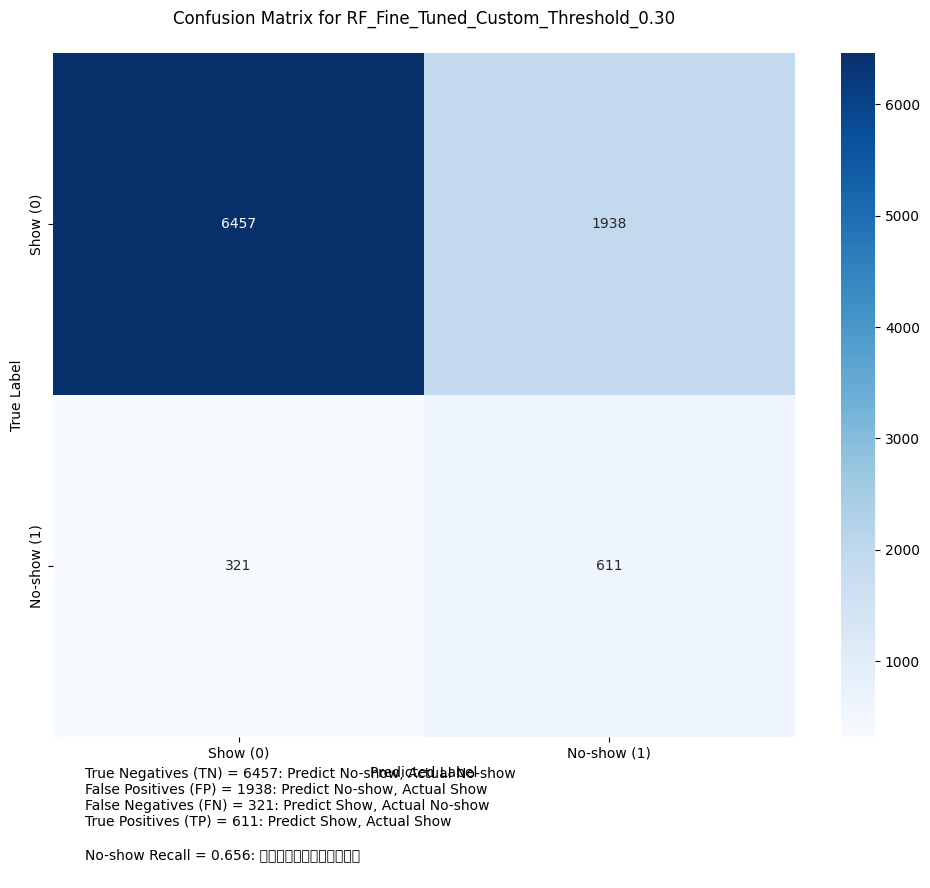

              precision    recall  f1-score   support

           0       0.95      0.77      0.85      8395
           1       0.24      0.66      0.35       932

    accuracy                           0.76      9327
   macro avg       0.60      0.71      0.60      9327
weighted avg       0.88      0.76      0.80      9327

roc_auc:  0.7791211558075394


{'precision': 0.23970184386033738,
 'recall': 0.6555793991416309,
 'f1': 0.3510485492674519,
 'accuracy': np.float64(0.7577999356706336),
 'roc_auc': np.float64(0.7791211558075394),
 'true_positives': np.int64(611),
 'false_positives': np.int64(1938),
 'true_negatives': np.int64(6457),
 'false_negatives': np.int64(321)}

In [94]:
threshold = 0.30
y_pred_custom = (y_proba_rf_weighted_best >= threshold).astype(int)
evaluate_model(y_test, y_pred_custom, y_proba_rf_weighted_best, "RF_Fine_Tuned_Custom_Threshold_0.30")

In [95]:
grid_rf_fine.fit(X_train_balanced, y_train_balanced)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=  11.9s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=  12.4s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=  12.7s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=  12.8s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=180; total time=  12.9s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  14.0s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt,

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 8},
                                          {0: 1, 1: 10}, {0: 1, 1: 12}],
                         'max_depth': [None, 30, 40],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [180, 200, 220]},
             refit='cost_savings',
             scoring={'cost_savings': make_scorer(<lambda>, response_method='predict'),
                      'recall': make_scorer(recall_score, response_method='predict', pos_label=1),
                      'roc_auc': 'roc_auc'},
             verbose=2)


最佳參數: {'class_weight': {0: 1, 1: 12}, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

最佳模型評估:


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

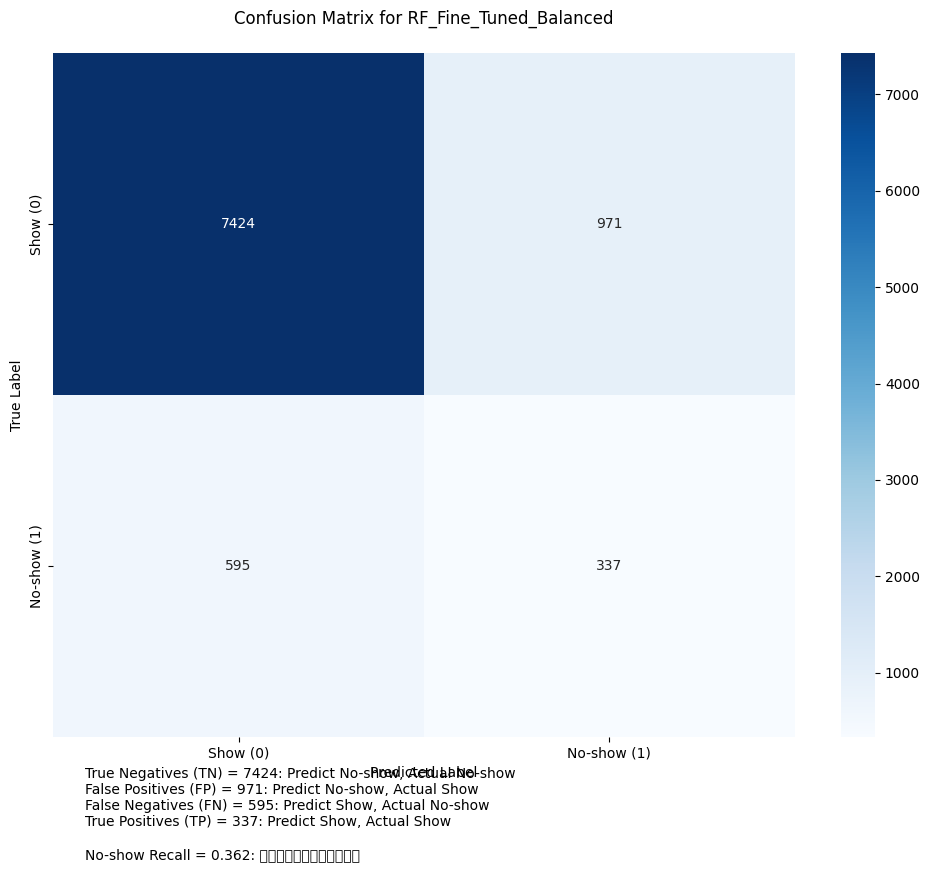

              precision    recall  f1-score   support

           0       0.93      0.88      0.90      8395
           1       0.26      0.36      0.30       932

    accuracy                           0.83      9327
   macro avg       0.59      0.62      0.60      9327
weighted avg       0.86      0.83      0.84      9327

roc_auc:  0.7453175684484173
Best threshold based on cost savings: 0.30000000000000004

閾值優化結果:
   threshold  true_positives  false_positives  false_negatives    recall  \
4       0.30             721             3457              211  0.773605   
5       0.35             615             2532              317  0.659871   
6       0.40             510             1876              422  0.547210   
3       0.25             805             4549              127  0.863734   
7       0.45             423             1335              509  0.453863   

   precision  cost_savings  
4   0.172571         60640  
5   0.195424         60060  
6   0.213747         54280  
3   

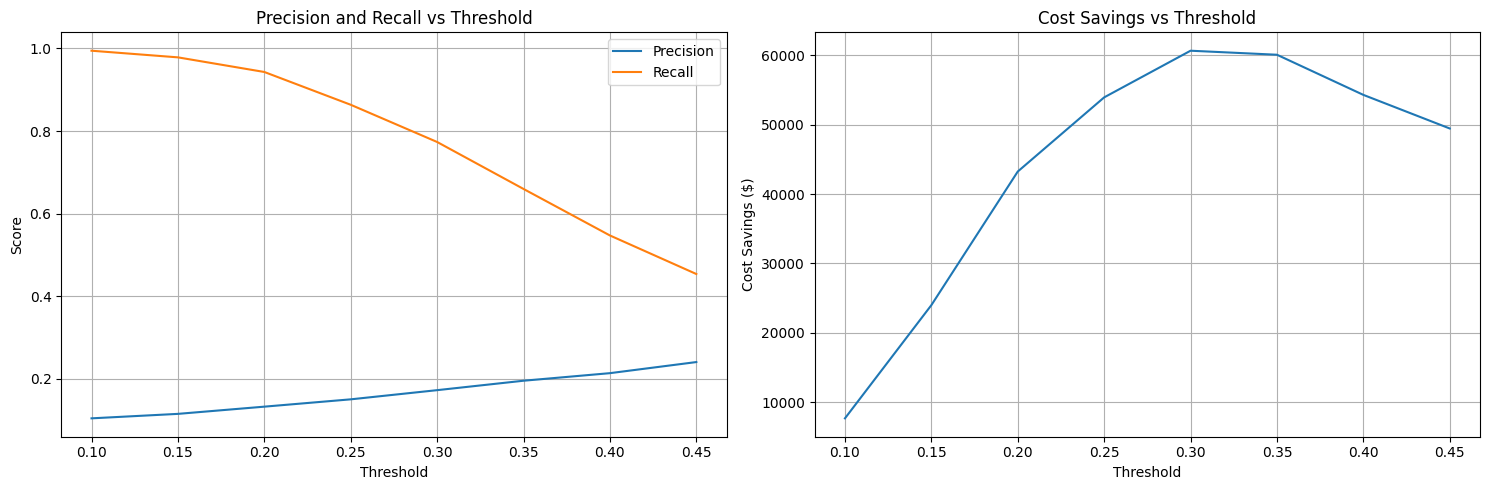


Best Threshold Results:
Threshold: 0.300
Precision: 0.173
Recall: 0.774
Cost Savings: $60,640.00
True Positives: 721.0
False Positives: 3457.0
False Negatives: 211.0


In [96]:
# 5. 獲取最佳模型
best_rf_balanced = grid_rf_fine.best_estimator_
print("\n最佳參數:", grid_rf_fine.best_params_)

# 6. 評估最佳模型
y_pred_rf_balanced_best = best_rf_balanced.predict(X_test_final)
y_proba_rf_balanced_best = best_rf_balanced.predict_proba(X_test_final)[:, 1]

# 7. 詳細評估
print("\n最佳模型評估:")
evaluate_model(y_test, y_pred_rf_balanced_best, y_proba_rf_balanced_best, "RF_Fine_Tuned_Balanced")

# 8. 閾值優化
results_df = evaluate_threshold(y_test, y_proba_rf_balanced_best)
print("\n閾值優化結果:")
print(results_df.sort_values('cost_savings', ascending=False).head())

visualize_threshold_results(results_df)

### XGBoost

In [22]:
import xgboost as xgb

In [23]:
# Compute ratio: (negative class / positive class) for imbalanced data
# So that the model pays more attention to the minority class
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", ratio)


scale_pos_weight: 9.007242489270386


In [24]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,    
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

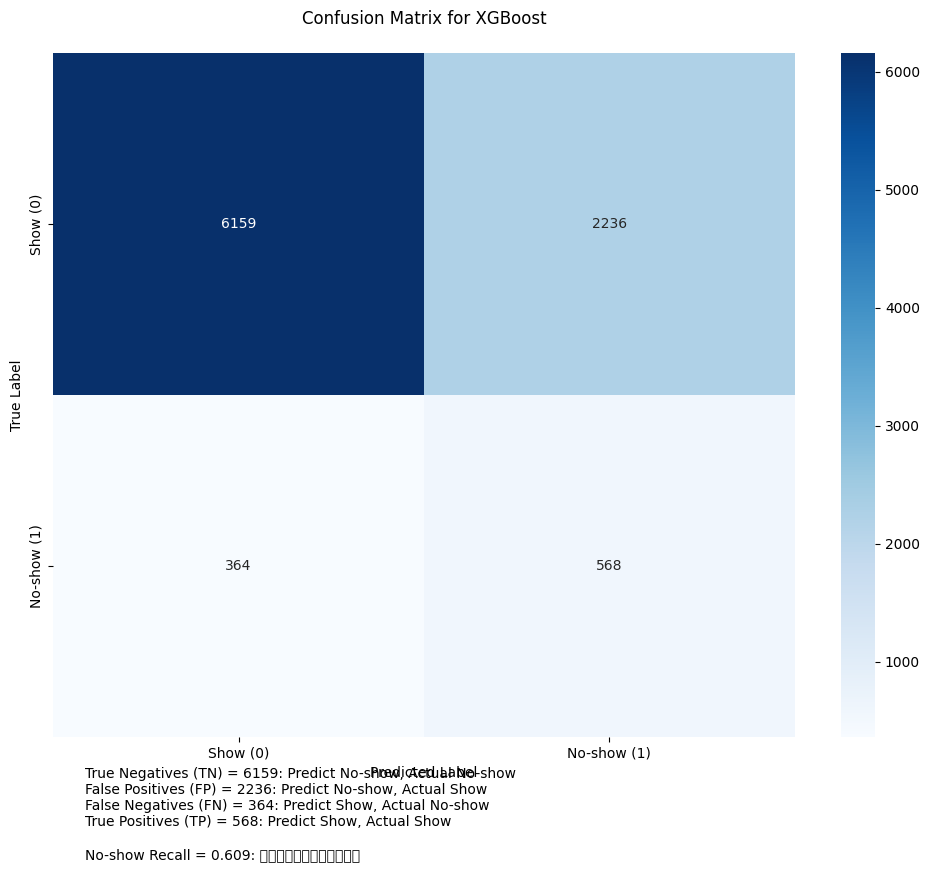

              precision    recall  f1-score   support

           0       0.94      0.73      0.83      8395
           1       0.20      0.61      0.30       932

    accuracy                           0.72      9327
   macro avg       0.57      0.67      0.56      9327
weighted avg       0.87      0.72      0.77      9327

roc_auc:  0.739316078188785


{'precision': 0.20256776034236804,
 'recall': 0.6094420600858369,
 'f1': 0.30406852248394006,
 'accuracy': np.float64(0.7212394124584539),
 'roc_auc': np.float64(0.739316078188785),
 'true_positives': np.int64(568),
 'false_positives': np.int64(2236),
 'true_negatives': np.int64(6159),
 'false_negatives': np.int64(364)}

In [25]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")


In [26]:
threshold = 0.35
y_pred_custom = (y_proba_xgb >= threshold).astype(int)
print("Custom Threshold Report:")
print(classification_report(y_test, y_pred_custom))


Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.97      0.45      0.61      8395
           1       0.15      0.86      0.25       932

    accuracy                           0.49      9327
   macro avg       0.56      0.65      0.43      9327
weighted avg       0.88      0.49      0.57      9327



## For Shows (Class 0):
1. Precision: 0.97 → 97% of patients predicted to show up actually showed up (improved)
2. Recall: 0.44 → Only 44% of actual show-ups were correctly identified (decreased)
3. F1-score: 0.61 → Moderate balanced performance for show-ups

## For No-shows (Class 1):
1. Precision: 0.15 → Only 15% of patients predicted to no-show actually didn't show up
2. Recall: 0.86 → 86% of actual no-shows were correctly identified (significantly improved)
3. F1-score: 0.25 → Still weak overall performance, but better at catching no-shows

In [27]:
## Fine Tuning XGBoost Model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],              # Add to prevent overfitting                    
    'reg_alpha': [0, 0.1, 1.0],                 # L1 regularization
    'reg_lambda': [0, 1.0, 5.0]                 # L2 regularization
}

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)

# grid_search = GridSearchCV(
#     estimator=xgb_clf,
#     param_grid=param_grid,
#     scoring='recall',         # optimize for recall!
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=200,             
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=2
)





In [28]:
# grid_search.fit(X_train, y_train)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, reg_alpha=0.1, reg_lambda=0, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, reg_alpha=0.1, reg_lambda=0, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, reg_alpha=0.1, reg_lambda=0, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0, reg_lambda=1.0, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=200, reg_alpha=1.0, reg_lambda=0, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=200, reg_alpha=1.0, 

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [3, 5],
                                        'min_child_weight': [1, 3],
                                        'n_estimators': [100, 200],
                                        'reg_alpha': [0, 0.1, 1.0],
                                        'reg_lambda': [0, 1.0, 5.0],
                                        'subsample': [0.8, 1.0]},
                   scoring='recall', verbose=2)

Best parameters: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

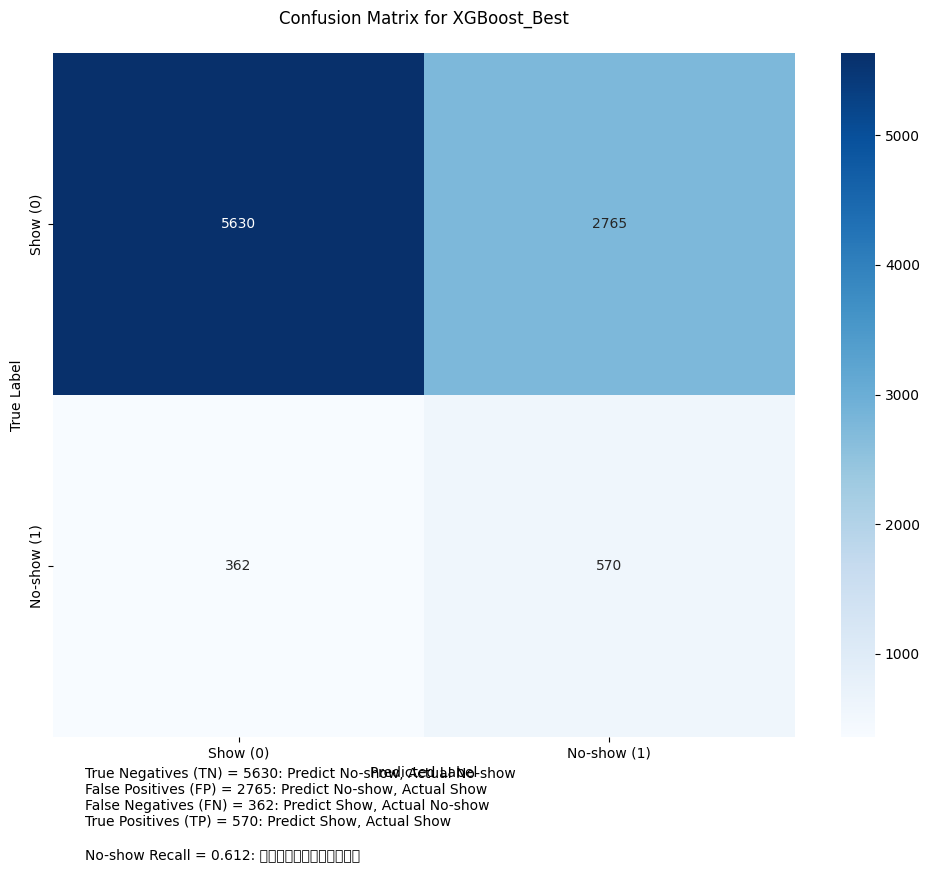

              precision    recall  f1-score   support

           0       0.94      0.67      0.78      8395
           1       0.17      0.61      0.27       932

    accuracy                           0.66      9327
   macro avg       0.56      0.64      0.52      9327
weighted avg       0.86      0.66      0.73      9327

roc_auc:  0.6995439754401124
Best threshold based on cost savings: 0.4500000000000001


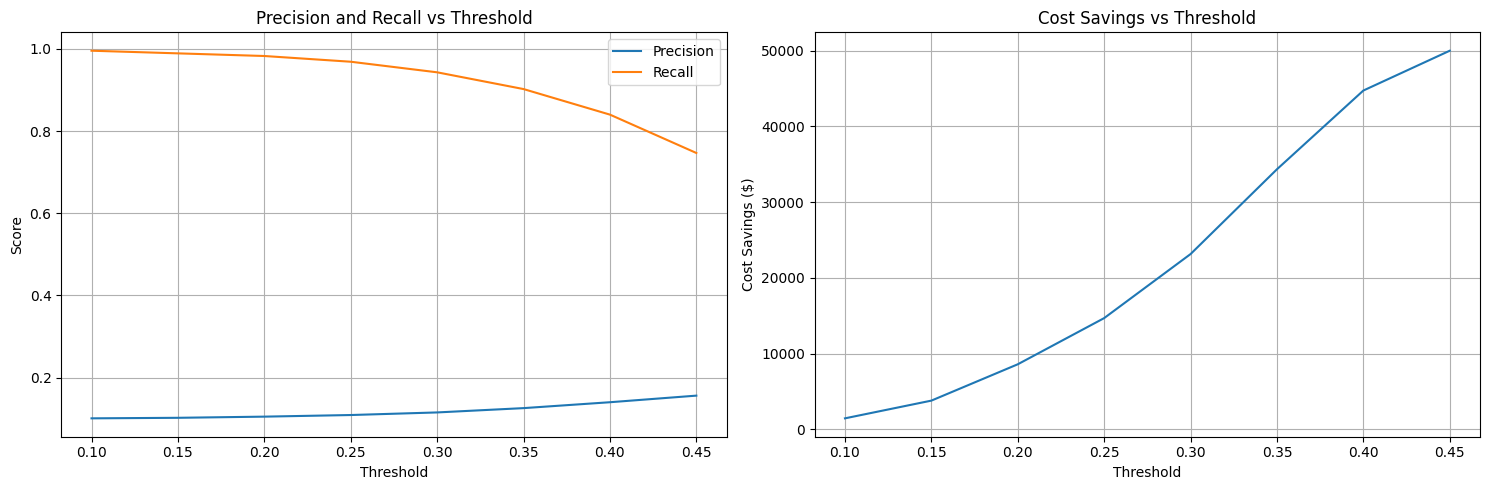


Best Threshold Results:
Threshold: 0.450
Precision: 0.156
Recall: 0.747
Cost Savings: $50,000.00
True Positives: 696.0
False Positives: 3764.0
False Negatives: 236.0


In [29]:
best_xgb = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

# Predict and evaluate
y_pred_xgb_best = best_xgb.predict(X_test)
y_proba_xgb_best = best_xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_xgb_best, y_proba_xgb_best, "XGBoost_Best")
results_df = evaluate_threshold(y_test, y_proba_xgb_best)
visualize_threshold_results(results_df)


In [78]:
threshold = 0.45
y_pred_thresholded = (y_proba_xgb_best >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))


Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70      8395
           1       0.16      0.75      0.26       932

    accuracy                           0.57      9327
   macro avg       0.55      0.65      0.48      9327
weighted avg       0.87      0.57      0.65      9327



<Figure size 1000x600 with 0 Axes>

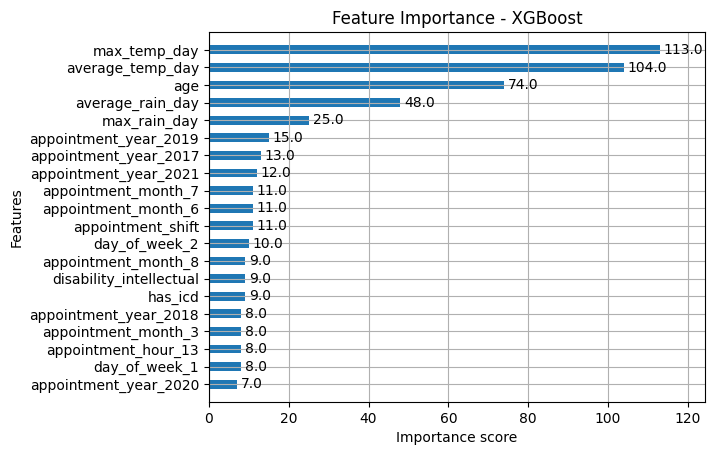

In [79]:
# # Feature Importance

plot_feature_importance_xgb(best_xgb)

['max_temp_day', 'average_temp_day', 'age', 'average_rain_day', 'max_rain_day', 'appointment_year_2019', 'appointment_year_2017', 'appointment_year_2021', 'appointment_shift', 'appointment_month_6', 'appointment_month_7', 'day_of_week_2', 'has_icd', 'disability_intellectual', 'appointment_month_8']
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      8395
           1       0.21      0.61      0.32       932

    accuracy                           0.74      9327
   macro avg       0.58      0.68      0.58      9327
weighted avg       0.87      0.74      0.78      9327



/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

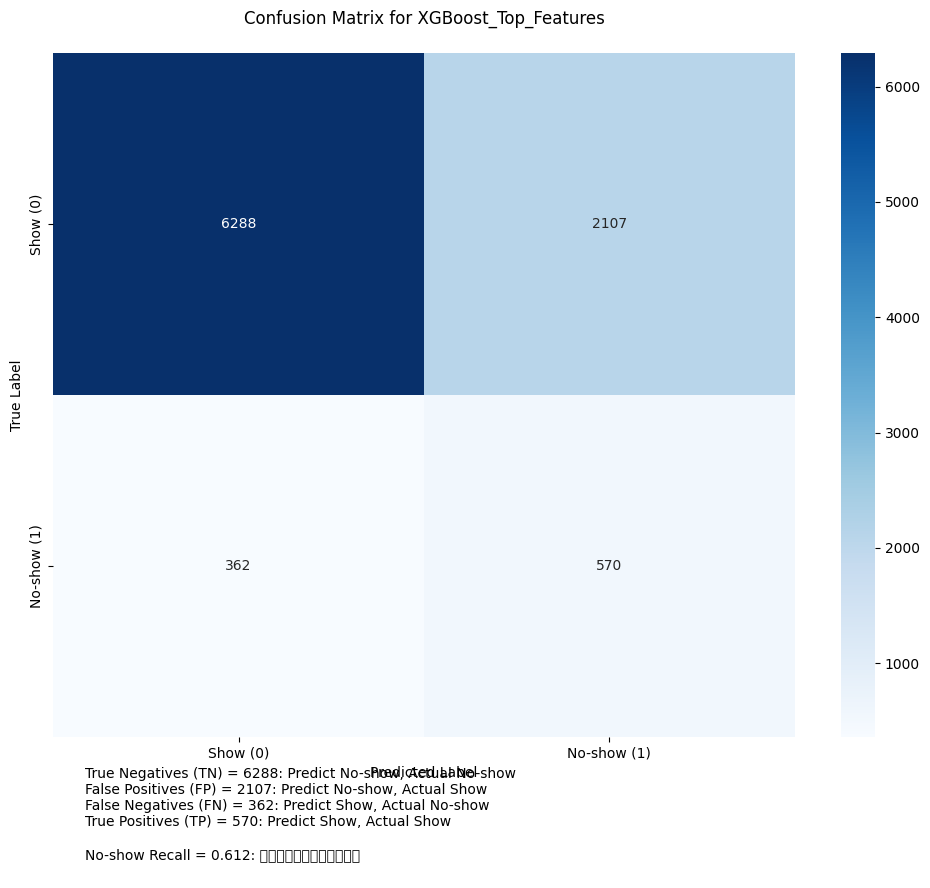

              precision    recall  f1-score   support

           0       0.95      0.75      0.84      8395
           1       0.21      0.61      0.32       932

    accuracy                           0.74      9327
   macro avg       0.58      0.68      0.58      9327
weighted avg       0.87      0.74      0.78      9327

roc_auc:  0.7468580572433519
Best threshold based on cost savings: 0.4500000000000001


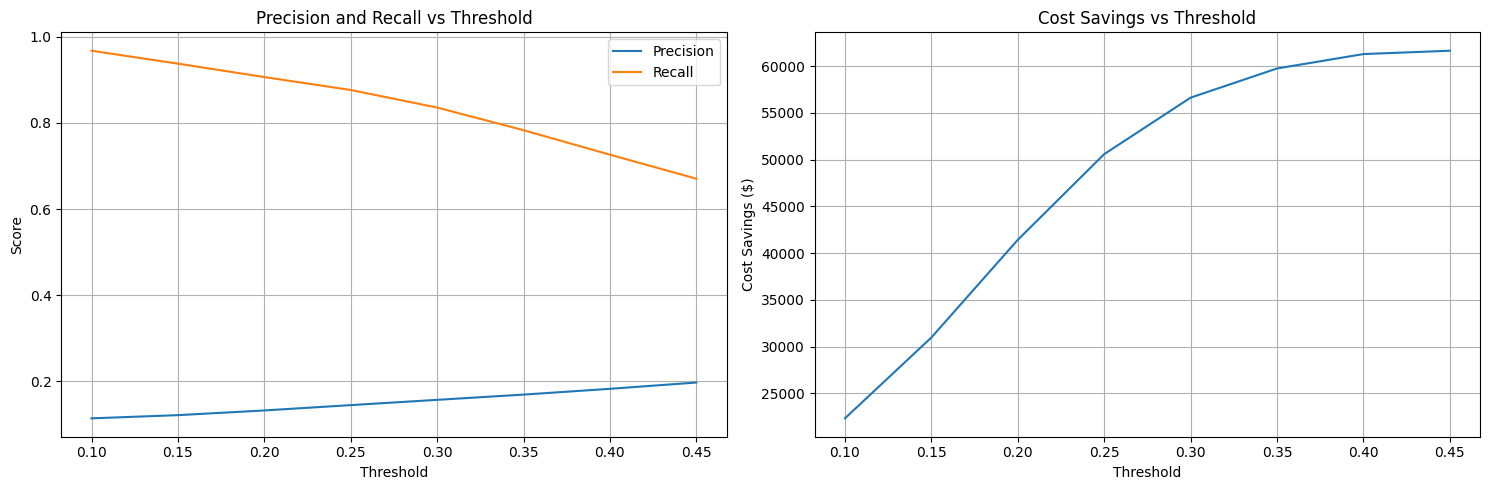


Best Threshold Results:
Threshold: 0.450
Precision: 0.197
Recall: 0.671
Cost Savings: $61,640.00
True Positives: 625.0
False Positives: 2543.0
False Negatives: 307.0


In [ ]:
# Top features based on feature importance score
# Select top 15 features
importances = best_xgb.get_booster().get_score(importance_type='weight')
top_features = sorted(importances, key=importances.get, reverse=True)[:15]
print(top_features)

# Create a dataset with only top features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]


# Train model with just these features
xgb_top = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)

xgb_top.fit(X_train_top, y_train)

# Compare performance with full-feature model
y_pred_top_xgb = xgb_top.predict(X_test_top)
print(classification_report(y_test, y_pred_top_xgb))
y_proba_top_xgb = xgb_top.predict_proba(X_test_top)[:, 1]

evaluate_model(y_test, y_pred_top_xgb, y_proba_top_xgb, "XGBoost_Top_Features")
results_df = evaluate_threshold(y_test, y_proba_top_xgb)
visualize_threshold_results(results_df)


In [33]:
threshold = 0.45
y_pred_thresholded = (y_proba_top_xgb >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))


Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      8395
           1       0.20      0.67      0.31       932

    accuracy                           0.70      9327
   macro avg       0.57      0.68      0.56      9327
weighted avg       0.88      0.70      0.76      9327



In [34]:
# Further Enhance Model Performance by creating interactions between features
# Create interactions between top features
X_train_enhanced = X_train[top_features].copy()
X_test_enhanced = X_test[top_features].copy()

# Weather x Age interactions
X_train_enhanced['temp_age_interaction'] = X_train['max_temp_day'] * X_train['age']
X_test_enhanced['temp_age_interaction'] = X_test['max_temp_day'] * X_test['age']

X_train_enhanced['rain_age_interaction'] = X_train['average_rain_day'] * X_train['age']
X_test_enhanced['rain_age_interaction'] = X_test['average_rain_day'] * X_test['age']

# Month x Weather interactions
for month in ['appointment_month_6', 'appointment_month_7', 'appointment_month_8']:
    X_train_enhanced[f'{month}_temp'] = X_train[month] * X_train['max_temp_day']
    X_test_enhanced[f'{month}_temp'] = X_test[month] * X_test['max_temp_day']
    
    X_train_enhanced[f'{month}_rain'] = X_train[month] * X_train['average_rain_day']
    X_test_enhanced[f'{month}_rain'] = X_test[month] * X_test['average_rain_day']



In [35]:
# Focus parameter grid on feature-related parameters
focused_param_grid = {
    'n_estimators': [200, 300],          # Reduced options
    'max_depth': [4, 6],                 # Reduced options
    'learning_rate': [0.05, 0.1],        # Smaller learning rates
    'colsample_bytree': [0.6, 0.7, 0.8], # Focus on feature sampling
    'subsample': [0.8, 0.9],             # Less row sampling variation
    'gamma': [0.1, 0.3, 0.5],            # More focus on feature split quality
    'min_child_weight': [1, 3]           # Fewer options
}

# Create model for grid search
xgb_focused = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)

# Run grid search
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with custom metric focusing on recall
from sklearn.metrics import make_scorer, fbeta_score
custom_scorer = make_scorer(fbeta_score, beta=2)

grid_search_focused = GridSearchCV(
    estimator=xgb_focused,
    param_grid=focused_param_grid,
    scoring=custom_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Fit on enhanced features dataset
grid_search_focused.fit(X_train_enhanced, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rat

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8],
                         'gamma': [0.1, 0.3, 0.5], 'learning_rate': [0.05, 0.1],
                         'max_depth': [4, 6], 'min_child_weight': [1, 3],
                         'n_estimators': [200, 300], 'subsample': [0.8, 0.9]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
             verbose=2)

Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.9}


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

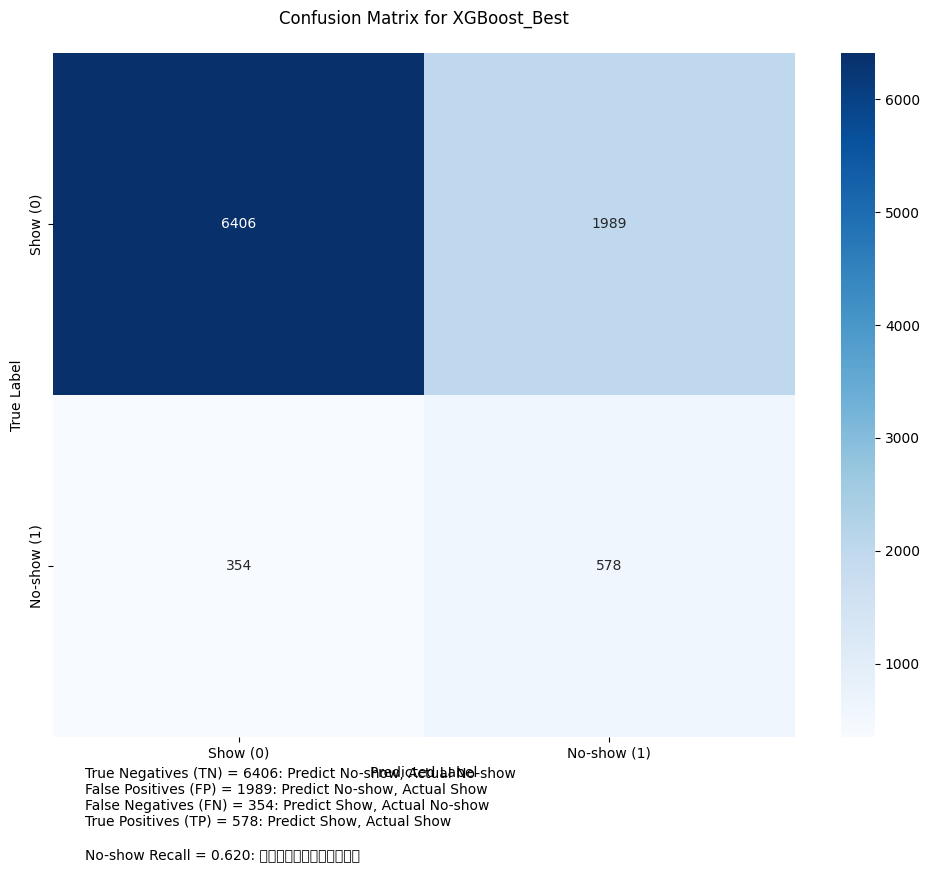

              precision    recall  f1-score   support

           0       0.95      0.76      0.85      8395
           1       0.23      0.62      0.33       932

    accuracy                           0.75      9327
   macro avg       0.59      0.69      0.59      9327
weighted avg       0.88      0.75      0.79      9327

roc_auc:  0.7571696697656229
Best threshold based on cost savings: 0.4500000000000001


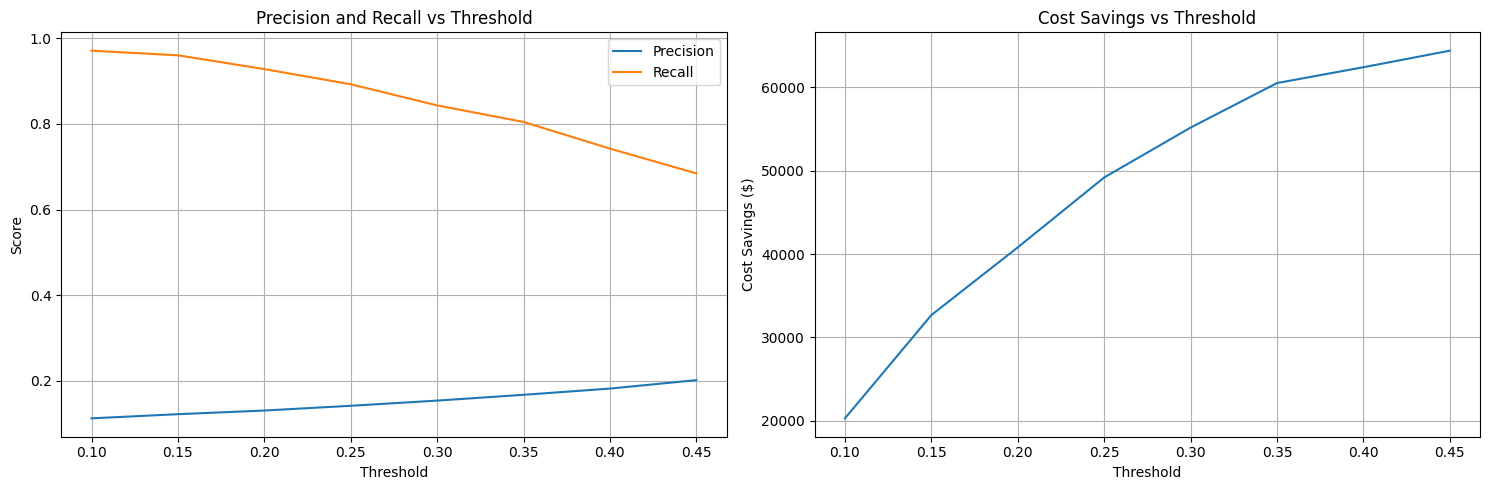


Best Threshold Results:
Threshold: 0.450
Precision: 0.202
Recall: 0.685
Cost Savings: $64,380.00
True Positives: 638.0
False Positives: 2523.0
False Negatives: 294.0


In [36]:
# Get best model from grid search
best_model = grid_search_focused.best_estimator_

print("Best parameters:", grid_search_focused.best_params_)

# Predict and evaluate
y_pred_best_enhanced = best_model.predict(X_test_enhanced)
y_proba_best_enhanced = best_model.predict_proba(X_test_enhanced)[:, 1]

evaluate_model(y_test, y_pred_best_enhanced, y_proba_best_enhanced, "XGBoost_Best")
results_df = evaluate_threshold(y_test, y_proba_best_enhanced)
visualize_threshold_results(results_df)



In [37]:
threshold = 0.45
y_pred_thresholded = (y_proba_best_enhanced >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))



Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      8395
           1       0.20      0.68      0.31       932

    accuracy                           0.70      9327
   macro avg       0.58      0.69      0.56      9327
weighted avg       0.88      0.70      0.76      9327



Best threshold based on cost savings: 0.4500000000000001
Best threshold based on cost savings: 0.1
Best threshold based on cost savings: 0.30000000000000004
Best threshold based on cost savings: 0.30000000000000004
Best threshold based on cost savings: 0.4500000000000001
Best threshold based on cost savings: 0.4500000000000001
Best threshold based on cost savings: 0.4500000000000001
Best threshold based on cost savings: 0.4500000000000001

Model Comparison with Optimized Thresholds:
                             Model  Best Threshold  Recall (No-show)  \
2         Random Forest (Original)            0.30          0.655579   
7               XGBoost (Enhanced)            0.45          0.684549   
6           XGBoost (Top Features)            0.45          0.670601   
3  Random Forest (SMOTE__Balanced)            0.30          0.773605   
4                          XGBoost            0.45          0.709227   
1                              SVM            0.10          0.656652   
5       

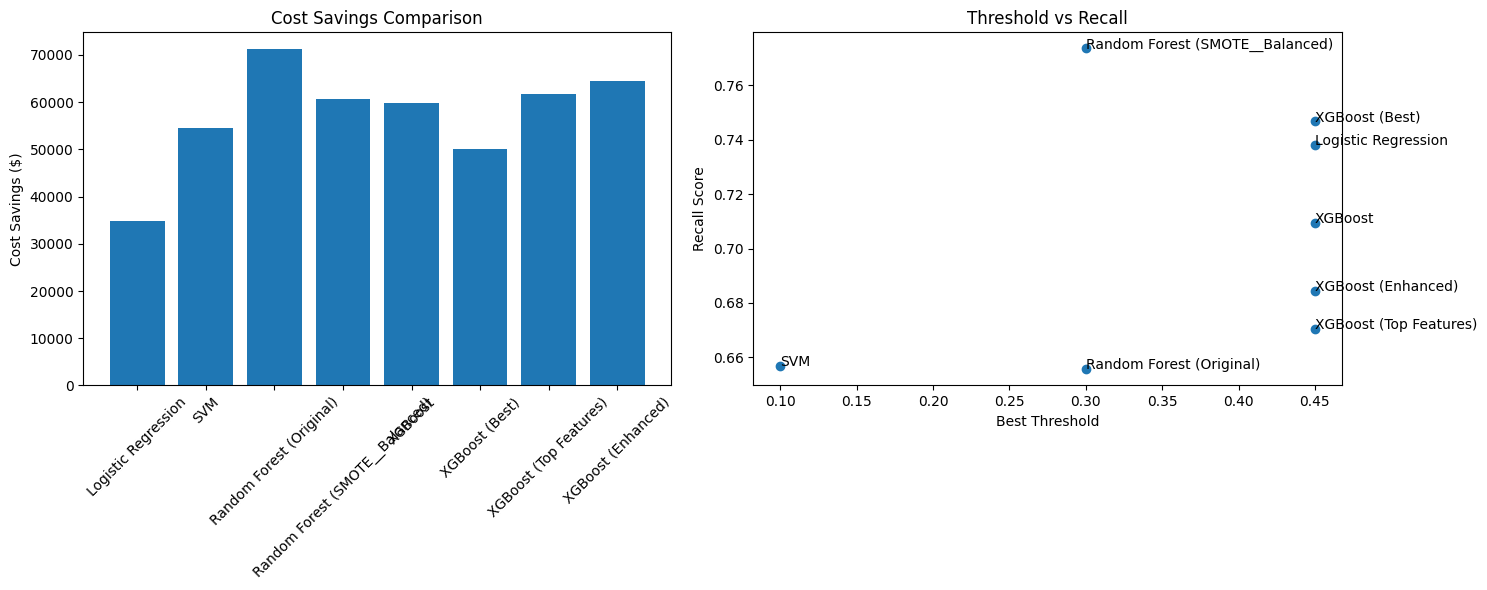

In [116]:
def optimize_and_compare_models(models_dict):
    """
    為每個模型找出最佳閾值並比較結果
    
    models_dict = {
        'model_name': {
            'y_proba': probabilities,
            'y_test': true_labels
        }
    }
    """
    comparison_results = []
    
    for model_name, data in models_dict.items():
        # 使用evaluate_threshold找出最佳閾值
        results_df = evaluate_threshold(data['y_test'], data['y_proba'])
        
        # 找出最佳成本節省的閾值
        best_idx = results_df['cost_savings'].idxmax()
        best_result = results_df.loc[best_idx]
        
        # 使用最佳閾值的預測結果
        y_pred_best = (data['y_proba'] >= best_result['threshold']).astype(int)
        tn, fp, fn, tp = confusion_matrix(data['y_test'], y_pred_best).ravel()
        
        # 計算詳細成本
        no_show_cost = 200  # 每個未檢測到的no-show成本
        intervention_cost = 20  # 每次干預成本
        
        total_savings = (tp * no_show_cost) - ((fp + tp) * intervention_cost)
        missed_cost = fn * no_show_cost
        intervention_total_cost = (fp + tp) * intervention_cost
        
        comparison_results.append({
            'Model': model_name,
            'Best Threshold': best_result['threshold'],
            'Recall (No-show)': tp / (tp + fn),
            'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
            'True Positives': tp,
            'False Positives': fp,
            'False Negatives': fn,
            'Cost Savings ($)': total_savings,
            'Missed No-show Cost ($)': missed_cost,
            'Intervention Cost ($)': intervention_total_cost
        })
    
    # 創建比較表格
    comparison_df = pd.DataFrame(comparison_results)
    
    # 格式化數值
    # format_dict = {
    #     'Best Threshold': '{:.3f}',
    #     'Recall (No-show)': '{:.3f}',
    #     'Precision': '{:.3f}',
    #     'Cost Savings ($)': '${:,.0f}',
    #     'Missed No-show Cost ($)': '${:,.0f}',
    #     'Intervention Cost ($)': '${:,.0f}'
    # }
    
    # for col, format_str in format_dict.items():
    #     comparison_df[col] = comparison_df[col].map(format_str.format)
    
    return comparison_df

# 準備模型結果
models_dict = {
    'Logistic Regression': {
        'y_proba': y_proba_lg,
        'y_test': y_test
    },
    'SVM': {
        'y_proba': y_proba_svm,
        'y_test': y_test
    },
    'Random Forest (Original)': {
        'y_proba': y_proba_rf_weighted_best,
        'y_test': y_test
    },
    
    'Random Forest (SMOTE__Balanced)': {
        'y_proba': y_proba_rf_balanced_best,
        'y_test': y_test
    },
    'XGBoost': {
        'y_proba': y_proba_xgb,
        'y_test': y_test
    },
    'XGBoost (Best)': {
        'y_proba': y_proba_xgb_best,
        'y_test': y_test
    },
    'XGBoost (Top Features)': {
        'y_proba': y_proba_top_xgb,
        'y_test': y_test
    },
    'XGBoost (Enhanced)': {
        'y_proba': y_proba_best_enhanced,
        'y_test': y_test
    }
}

# 生成比較表    
comparison_df = optimize_and_compare_models(models_dict)

# 顯示結果
print("\nModel Comparison with Optimized Thresholds:")
print(comparison_df.sort_values('Cost Savings ($)', ascending=False))

# 計算總節省成本
total_savings = comparison_df['Cost Savings ($)'].max()
print(f"\nMaximum Potential Cost Savings: ${total_savings:,.2f}")

import matplotlib.pyplot as plt
# 視覺化比較
plt.figure(figsize=(15, 6))

# 成本節省比較
plt.subplot(1, 2, 1)
costs = comparison_df['Cost Savings ($)']
plt.bar(comparison_df['Model'], costs)
plt.title('Cost Savings Comparison')
plt.xticks(rotation=45)
plt.ylabel('Cost Savings ($)')

# 閾值和召回率比較
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['Best Threshold'].astype(float), 
           comparison_df['Recall (No-show)'].astype(float))
plt.title('Threshold vs Recall')
plt.xlabel('Best Threshold')
plt.ylabel('Recall Score')
for i, model in enumerate(comparison_df['Model']):
    plt.annotate(model, 
                (comparison_df['Best Threshold'].astype(float).iloc[i],
                 comparison_df['Recall (No-show)'].astype(float).iloc[i]))

plt.tight_layout()
plt.show()

In [108]:
print(comparison_df)
print(comparison_df.keys())

                             Model Best Threshold Recall (No-show) Precision  \
0              Logistic Regression          0.450            0.738     0.134   
1                              SVM          0.100            0.657     0.180   
2         Random Forest (Original)          0.300            0.656     0.240   
3  Random Forest (SMOTE__Balanced)          0.300            0.774     0.173   
4                          XGBoost          0.450            0.709     0.183   
5                   XGBoost (Best)          0.450            0.747     0.156   
6           XGBoost (Top Features)          0.450            0.671     0.197   
7               XGBoost (Enhanced)          0.450            0.685     0.202   

   True Positives  False Positives  False Negatives Cost Savings ($)  \
0             688             4454              244          $34,760   
1             612             2782              320          $54,520   
2             611             1938              321          $7

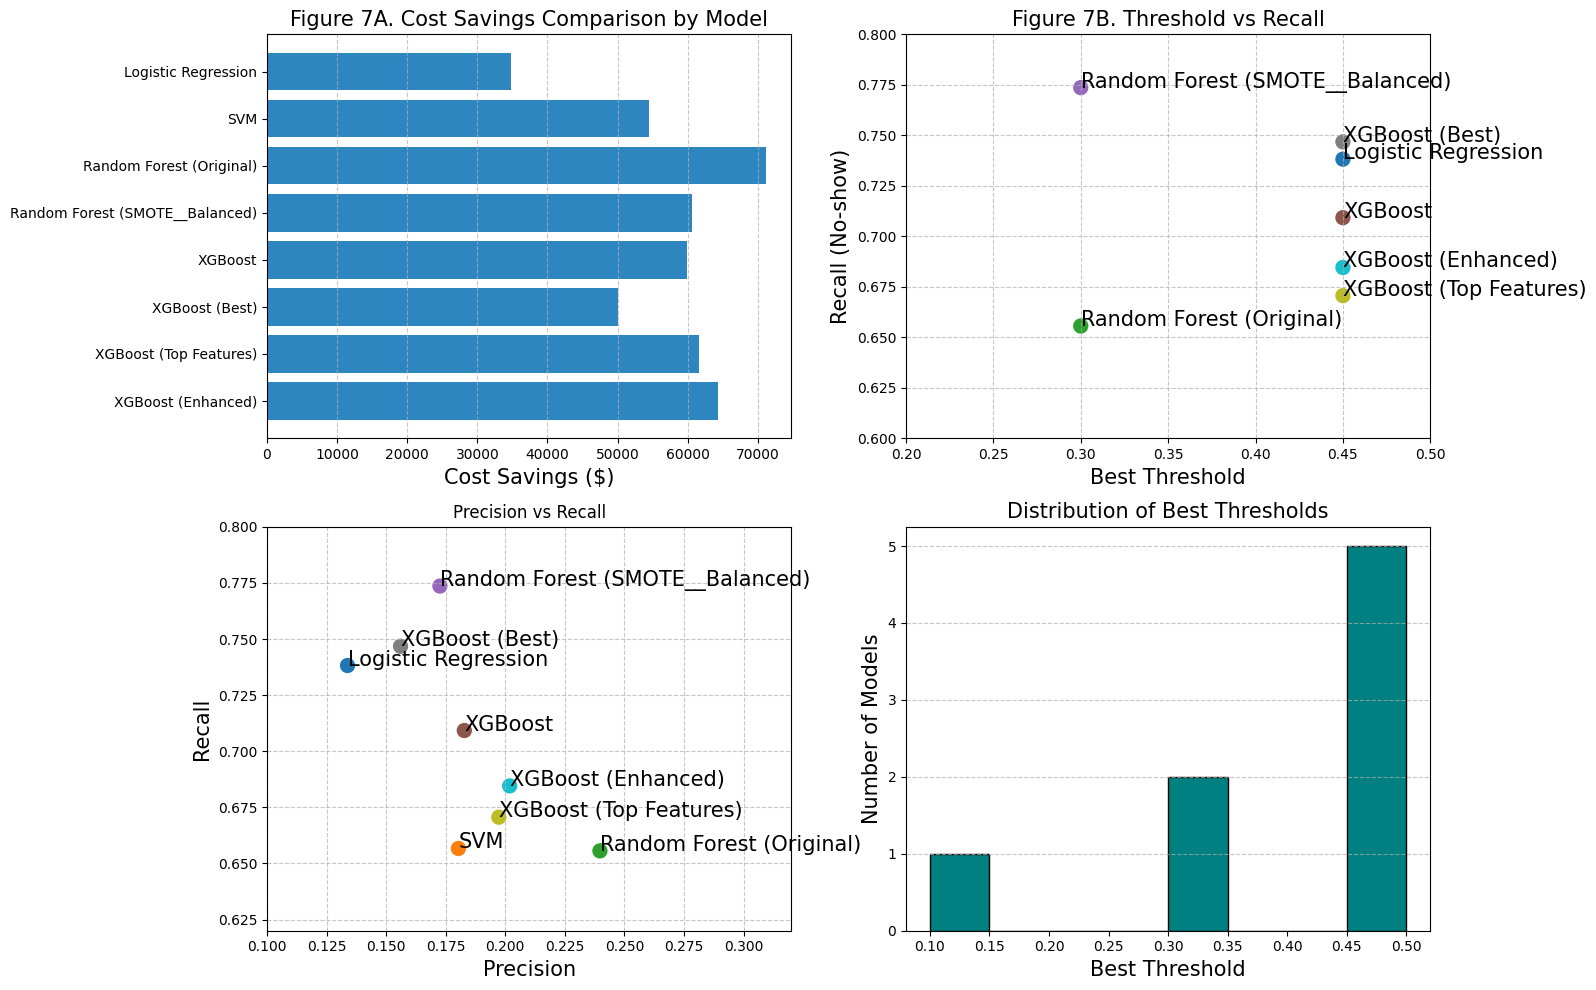

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_df)))

# Convert necessary columns to float if not already
comparison_df['Cost Savings ($)'] = comparison_df['Cost Savings ($)'].astype(float)
comparison_df['Best Threshold'] = comparison_df['Best Threshold'].astype(float)
comparison_df['Recall (No-show)'] = comparison_df['Recall (No-show)'].astype(float)
comparison_df['Precision'] = comparison_df['Precision'].astype(float)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# 1. Cost Savings Comparison
axs[0, 0].barh(comparison_df['Model'], comparison_df['Cost Savings ($)'], color='#2E86C1')
axs[0, 0].set_title('Figure 7A. Cost Savings Comparison by Model', fontsize=15)
axs[0, 0].set_xlabel('Cost Savings ($)', fontsize=15)
axs[0, 0].invert_yaxis()  # Highest at top
axs[0, 0].grid(axis='x', linestyle='--', alpha=0.7)

# 2. Threshold vs Recall
axs[0, 1].scatter(comparison_df['Best Threshold'], comparison_df['Recall (No-show)'], color= colors,s=100)
axs[0, 1].set_xlim(0.2, 0.5)
axs[0, 1].set_ylim(0.60, 0.80)
for i, row in comparison_df.iterrows():
    axs[0, 1].annotate(row['Model'], (row['Best Threshold'], row['Recall (No-show)']), fontsize=15)
axs[0, 1].set_title('Figure 7B. Threshold vs Recall', fontsize=15)
axs[0, 1].set_xlabel('Best Threshold', fontsize=15)
axs[0, 1].set_ylabel('Recall (No-show)', fontsize=15)
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# 3. Recall vs Precision (PR positioning)
axs[1, 0].scatter(comparison_df['Precision'], comparison_df['Recall (No-show)'], s=100, color=colors)
axs[1, 0].set_xlim(0.1, 0.32)
axs[1, 0].set_ylim(0.62, 0.80)
for i, row in comparison_df.iterrows():
    axs[1, 0].annotate(row['Model'], (row['Precision'], row['Recall (No-show)']), fontsize=15)
axs[1, 0].set_title('Precision vs Recall')
axs[1, 0].set_xlabel('Precision', fontsize=15)
axs[1, 0].set_ylabel('Recall', fontsize=15)
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# 4. Threshold Histogram
axs[1, 1].hist(comparison_df['Best Threshold'], bins=np.linspace(0.1, 0.5, 9), color='teal', edgecolor='black')
axs[1, 1].set_title('Distribution of Best Thresholds', fontsize=15)
axs[1, 1].set_xlabel('Best Threshold', fontsize=15)
axs[1, 1].set_ylabel('Number of Models', fontsize=15)
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
